# Chest X-Ray Thoracic Pathology Classification
 20-class Multi-label Classification**

**Metric:** Macro-averaged Asymmetric Cost Score  
- TP: +1, FP: -1, FN: -5  
- Strategy: Prioritize **Recall** (minimize False Negatives)

**Pipeline Overview:**
1. EDA & Data Loading
2. Dataset & DataLoader
3. EfficientNet-B0 Model
4. Asymmetric Loss + Class Weights
5. Training with recall-focused threshold tuning
6. Prediction & Submission
7. Export model for deployment

In [38]:
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()

# Imports

In [1]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [40]:
CFG = {
    'data_dir': '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1',         
    'img_dir': '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images',
    'img_size': 224,
    'batch_size': 32,
    'num_workers': 2,
    'epochs': 10,                 
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'model_name': 'efficientnet_b0',
    'dropout': 0.5,
    'threshold': 0.3,               # low threshold → high recall (penalize FN=-5)
    'model_path': '/kaggle/working/',
    'submission': '/kaggle/working/',
}

CLASSES = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema','Effusion',
    'Emphysema','Fibrosis','Hernia','Infiltration','Mass',
    'No Finding','Nodule','Pleural_Thickening','Pneumonia',
    'Pneumothorax','Enlarged Cardiomediastinum','Lung Opacity',
    'Lung Lesion','Fracture','Support Devices'
]
NUM_CLASSES = len(CLASSES)
print(f'Classes ({NUM_CLASSES}):', CLASSES)

Classes (20): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Enlarged Cardiomediastinum', 'Lung Opacity', 'Lung Lesion', 'Fracture', 'Support Devices']


# Loading Data

In [41]:
train_df = pd.read_csv(f"{CFG['data_dir']}/train.csv")
test_df = pd.read_csv(f"{CFG['data_dir']}/test.csv")
sample = pd.read_csv(f"{CFG['data_dir']}/sample_submission.csv")

# Auto-detect class columns (all columns except 'id')
CLASSES = [c for c in train_df.columns if c != 'id']
NUM_CLASSES = len(CLASSES)
print(f'Detected {NUM_CLASSES} classes: {CLASSES}')
print(f'Train shape: {train_df.shape} , Test shape: {test_df.shape}')
train_df.head()

Detected 20 classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']
Train shape: (51043, 21) | Test shape: (17015, 1)


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,977df638b5294072ac81c369e2d9ecd0.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4f6dd5e39cd548df904b7319b13a40c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,8772d25762484c2aa3f3e124d2ebcb30.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,31caeb0fa0814858bf4591bc1c8d63ac.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,9cd3df7acfbf4bb8a00466801469b08b.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Exploratory Data Analysis

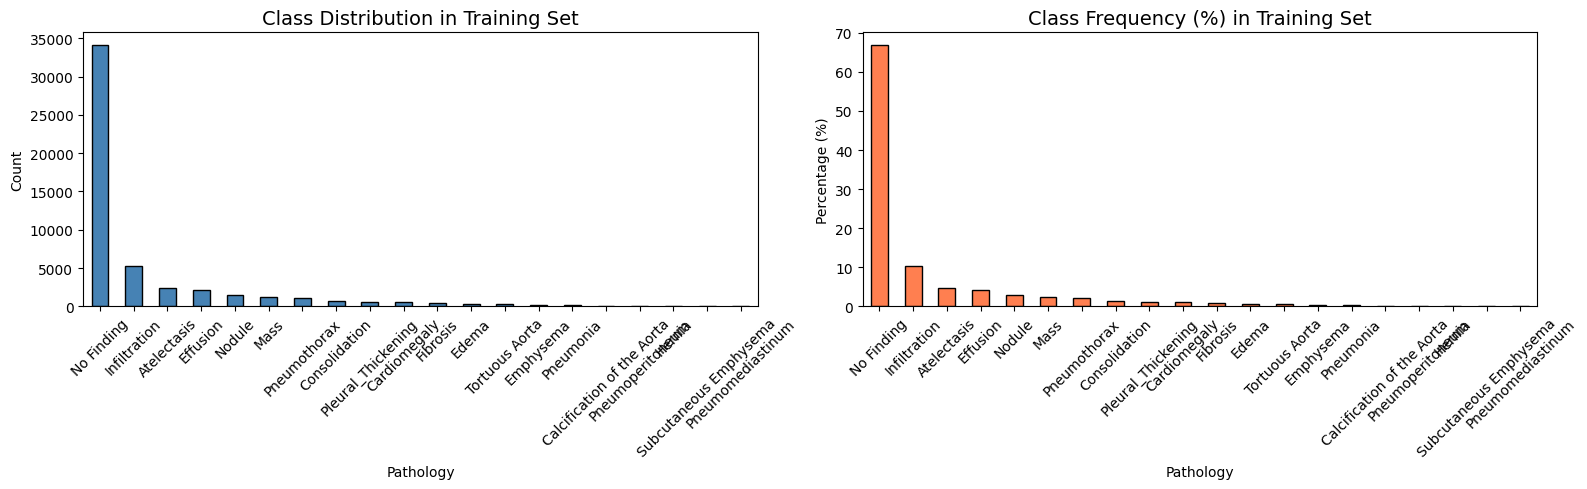


Class imbalance ratio (max/min): 6815.8


In [42]:
class_counts =train_df[CLASSES].sum().sort_values(ascending=False)

fig,axes= plt.subplots(1, 2, figsize=(16, 5))

# Class distribution
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution in Training Set', fontsize=14)
axes[0].set_xlabel('Pathology')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Class frequency as percentage
(class_counts / len(train_df) * 100).plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Class Frequency (%) in Training Set', fontsize=14)
axes[1].set_xlabel('Pathology')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('\nClass imbalance ratio (max/min):', round(class_counts.max() / class_counts.min(), 2))

In [43]:
# Compute Class Weights for Loss 
# Higher weight for rare classes
total= len(train_df)
pos_counts = train_df[CLASSES].sum().values
neg_counts =total - pos_counts

# pos_weight for BCEWithLogitsLoss: neg/pos ratio
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(DEVICE)
print('pos_weight range:', pos_weight.min().item(), '-', pos_weight.max().item())

pos_weight range: 0.4977845549583435 - 10207.59765625


In [44]:
def get_transforms(mode='train', img_size=224):
    if mode =='train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2(),
        ])


class XRayDataset(Dataset):
    def __init__(self, df, img_dir, classes, mode='train', img_size=224):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.classes = classes
        self.mode = mode
        self.tfm= get_transforms(mode, img_size)
        self.has_labels = all(c in df.columns for c in classes)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = row['id']

        # Support both 'img_id.png' and 'img_id' formats
        img_path = self.img_dir / str(img_id)
        if not img_path.exists():
            img_path = self.img_dir / f"{img_id}.png"
        if not img_path.exists():
            img_path = self.img_dir / f"{img_id}.jpg"

        img = np.array(Image.open(img_path).convert('RGB'))
        aug = self.tfm(image=img)
        x   = aug['image'].float()

        if self.has_labels:
            y = torch.tensor(row[self.classes].values.astype(np.float32))
            return x, y
        return x, img_id

In [45]:
# ─── 6. DataLoaders ─────────────────────────────────────────────────────────
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)), test_size=0.1, random_state=SEED,
    stratify=train_df[CLASSES].values.argmax(axis=1)  # stratify on dominant class
)

train_ds = XRayDataset(train_df.iloc[train_idx], CFG['img_dir'], CLASSES, 'train', CFG['img_size'])
val_ds= XRayDataset(train_df.iloc[val_idx],   CFG['img_dir'], CLASSES, 'val',   CFG['img_size'])
test_ds= XRayDataset(test_df,CFG['img_dir'], CLASSES, 'test',  CFG['img_size'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader= DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 45938 | Val: 5105 | Test: 17015


# Model

In [46]:
class XRayModel(nn.Module):
    def __init__(self, model_name='efficientnet_b0', num_classes=20, dropout=0.3, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        in_features   = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

model = XRayModel(CFG['model_name'], NUM_CLASSES, CFG['dropout']).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model: {CFG["model_name"]} | Parameters: {total_params:,}')

for param in model.backbone.parameters():
    param.requires_grad = False
print("Backbone frozen for first 2 epochs")

Model: efficientnet_b0 | Parameters: 4,673,680
Backbone frozen for first 2 epochs


In [47]:
#8. Asymmetric Loss (penalizes FN more)
class AsymmetricLoss(nn.Module):
    """
    Custom loss aligned with competition metric:
    TP=+1, FP=-1, FN=-5  →  FN weight = 5x FP weight
    """
    def __init__(self, pos_weight=None, fn_weight=5.0, fp_weight=1.0):
        super().__init__()
        self.fn_weight = fn_weight
        self.fp_weight = fp_weight
        self.bce = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight)

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs    = torch.sigmoid(logits)
        # Upweight FN samples (target=1, pred<0.5)
        fn_mask  = (targets == 1) & (probs < 0.5)
        weights  = torch.ones_like(bce_loss)
        weights[fn_mask] = self.fn_weight
        return (bce_loss * weights).mean()

criterion = AsymmetricLoss(pos_weight=None, fn_weight=5.0)
optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

In [48]:
# Score Function Used
def competition_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Macro-averaged asymmetric cost: TP=+1,FP=-1, FN=-5"""
    scores = []
    for c in range(y_true.shape[1]):
        yt, yp = y_true[:, c], y_pred[:, c]
        N  = len(yt)
        TP = ((yt == 1) & (yp == 1)).sum()
        FP = ((yt == 0) & (yp == 1)).sum()
        FN = ((yt == 1) & (yp == 0)).sum()
        scores.append((TP - FP - 5 * FN) / N)
    return float(np.mean(scores))

# Training Loop

In [49]:
history = {'train_loss': [], 'val_loss': [], 'val_score': []}
best_score = -np.inf
best_weights= None
no_improve = 0
for epoch in range(CFG['epochs']):
    
    if epoch == 2:
        for param in model.backbone.parameters():
            param.requires_grad = True
        print("Backbone unfrozen")

    model.train()
    train_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{CFG["epochs"]} [Train]'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)

        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
       
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validate 
    model.eval()
    val_loss  = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{CFG["epochs"]} [Val]'):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)
            val_loss  += loss.item()
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    val_loss  /= len(val_loader)
    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    val_preds  = (all_probs >= CFG['threshold']).astype(int)
    val_score  = competition_score(all_labels, val_preds)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_score'].append(val_score)

    print(f'Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Score: {val_score:.4f}')

    if val_score > best_score:
        best_score   = val_score
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve   = 0
        print(f'New best score: {best_score:.4f}')
    else:
        no_improve += 1
        print(f'No improvement ({no_improve}/3)')
        if no_improve >= 3:
            print(f'Early stopping at epoch {epoch+1}')
            break

print(f'\nBest Val Score: {best_score:.4f}')

Epoch 1/10 [Train]:   0%|          | 0/1436 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.2794 | Val Loss: 0.2556 | Val Score: -0.0820
  ✓ New best score: -0.0820


Epoch 2/10 [Train]:   0%|          | 0/1436 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/160 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 09 | Train Loss: 0.1620 | Val Loss: 0.2247 | Val Score: -0.0594
  No improvement (1/3)


Epoch 10/10 [Train]:   0%|          | 0/1436 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.1583 | Val Loss: 0.2268 | Val Score: -0.0584
  ✓ New best score: -0.0584

Best Val Score: -0.0584


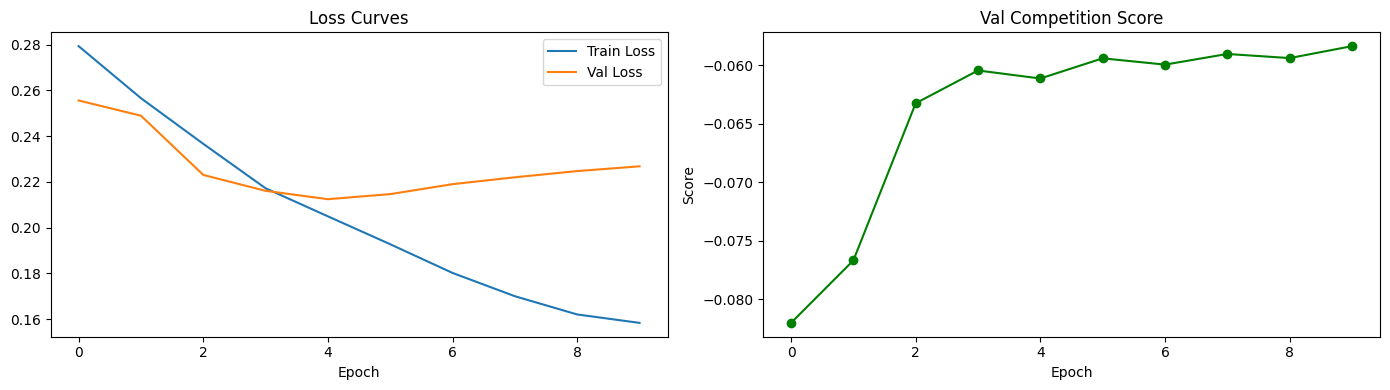

In [50]:
# ─── 11. Training Curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_score'], color='green', marker='o')
axes[1].set_title('Val Competition Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

Threshold tuning:   0%|          | 0/160 [00:00<?, ?it/s]

Best threshold: 0.40 → Score: -0.0537


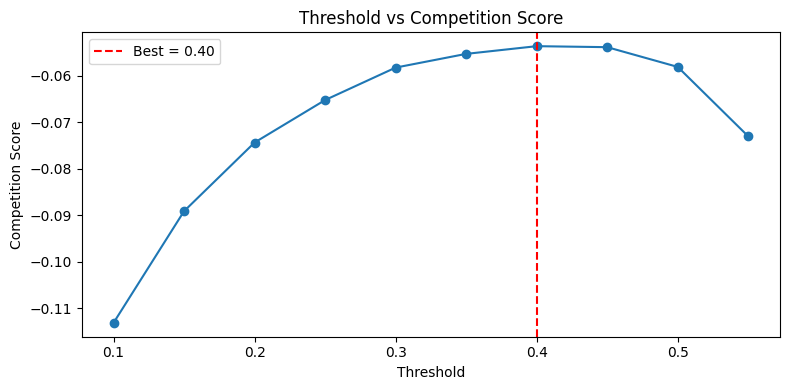

In [51]:
# Threshold Tuning on Validation Set 
# Load best weights first
model.load_state_dict(best_weights)
model.eval()

# Re-collect val probs with best model
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Threshold tuning'):
        imgs = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs  = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

# Grid search over thresholds
thresholds = np.arange(0.1, 0.6, 0.05)
scores     = [competition_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]

best_thresh = thresholds[np.argmax(scores)]
print(f'Best threshold: {best_thresh:.2f} → Score: {max(scores):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, scores, marker='o')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Competition Score')
plt.title('Threshold vs Competition Score')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

CFG['threshold'] = float(best_thresh)

                     class     score   recall   TP   FP  FN
              Infiltration -0.427816 0.495202  258 1127 263
               Atelectasis -0.200000 0.340426   80  326 155
                    Nodule -0.150049 0.156863   24  145 129
                  Effusion -0.123213 0.597222  129  323  87
                      Mass -0.093830 0.352000   44  118  81
              Pneumothorax -0.079922 0.387387   43  111  68
             Consolidation -0.067777 0.046154    3   39  62
        Pleural_Thickening -0.064055 0.065574    4   46  57
              Cardiomegaly -0.046817 0.400000   24   83  36
                  Fibrosis -0.041136 0.051282    2   27  37
                     Edema -0.032713 0.212121    7   44  26
            Tortuous Aorta -0.027032 0.120000    3   31  22
                 Emphysema -0.018805 0.000000    0   11  17
                 Pneumonia -0.015671 0.000000    0    0  16
Calcification of the Aorta -0.008815 0.000000    0    0   9
                    Hernia -0.003918 0.0

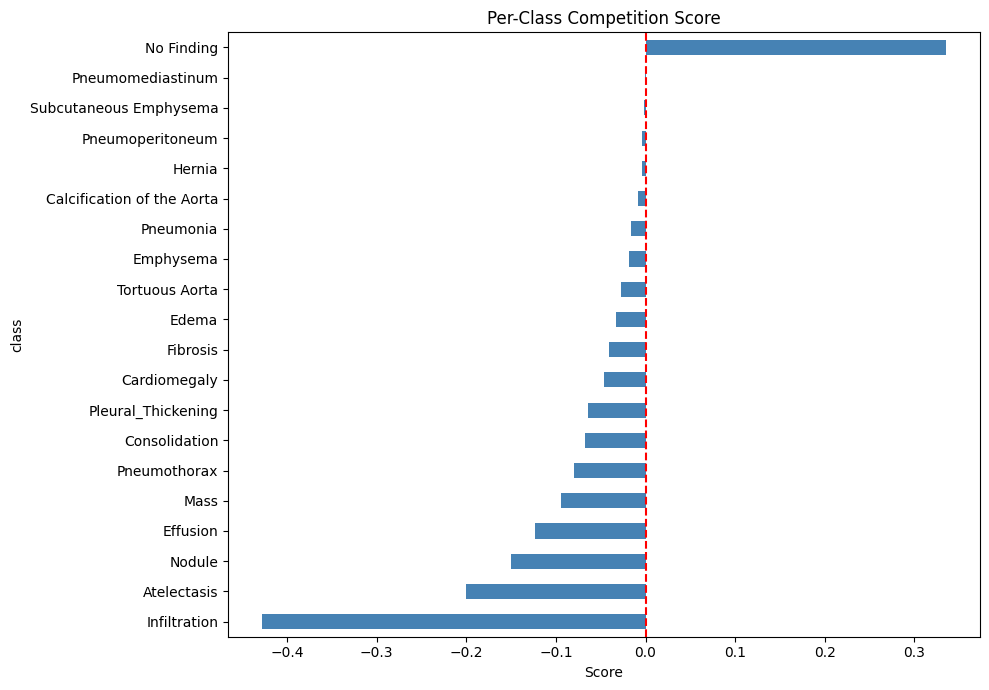

In [52]:
#  Per-Class Score Analysis 
val_preds = (all_probs >= CFG['threshold']).astype(int)

per_class = []
for i, cls in enumerate(CLASSES):
    yt, yp = all_labels[:, i], val_preds[:, i]
    N  = len(yt)
    TP = ((yt == 1) & (yp == 1)).sum()
    FP = ((yt == 0) & (yp == 1)).sum()
    FN = ((yt == 1) & (yp == 0)).sum()
    score = (TP - FP - 5 * FN) / N
    recall = TP / (TP + FN + 1e-9)
    per_class.append({'class': cls, 'score': score, 'recall': recall, 'TP': TP, 'FP': FP, 'FN': FN})

pc_df = pd.DataFrame(per_class).sort_values('score')
print(pc_df.to_string(index=False))

pc_df.plot(x='class', y='score', kind='barh', figsize=(10, 7), color='steelblue', legend=False)
plt.axvline(0, color='red', linestyle='--')
plt.title('Per-Class Competition Score')
plt.xlabel('Score')
plt.tight_layout()
plt.savefig('per_class_score.png', dpi=100, bbox_inches='tight')
plt.show()

In [53]:
# Generate Test Predictions 
model.eval()
all_test_probs = []
all_test_ids   = []

with torch.no_grad():
    for imgs, ids in tqdm(test_loader, desc='Predicting test'):
        imgs = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs)).cpu().numpy()
        all_test_probs.append(probs)
        all_test_ids.extend(ids)

all_test_probs = np.vstack(all_test_probs)
test_preds= (all_test_probs >= CFG['threshold']).astype(int)

# Ensure at least one class is predicted per image (argmax fallback)
for i in range(len(test_preds)):
    if test_preds[i].sum() == 0:
        test_preds[i, all_test_probs[i].argmax()] = 1

# Build submission
sub_df = pd.DataFrame(test_preds, columns=CLASSES)
sub_df.insert(0, 'id', all_test_ids)
sub_df.to_csv(CFG['submission'], index=False)
print(f'Submission saved to {CFG["submission"]}')
sub_df.head()

Predicting test:   0%|          | 0/532 [00:00<?, ?it/s]

Submission saved to ../submission.csv


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,1df09c3becd04de995244caae36ddf57.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,044cac47cfdf4c8b90848c9e56c36bfa.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,a873523c43664a049c5e8f26add7ecb2.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [55]:
# Save Model 
os.makedirs(Path(CFG['model_path']).parent, exist_ok=True)

deploy_bundle = {
    'model_state': {k: v.cpu() for k, v in best_weights.items()},
    'config': {
        'model_name'  : CFG['model_name'],
        'num_classes' : NUM_CLASSES,
        'dropout'     : CFG['dropout'],
        'img_size'    : CFG['img_size'],
        'threshold'   : CFG['threshold'],
        'classes'     : CLASSES,
    }
}

with open('/kaggle/working/model_new.pkl', 'wb') as f:
    pickle.dump(deploy_bundle, f)

print(f'Model saved to {CFG["model_path"]}')

torch.save(best_weights, str(Path(CFG['model_path']).parent / 'best_weights.pt'))
print('Done!')

Model saved to /kaggle/working/
Done!
